In [1]:
import logging
import warnings

import numpy as np

np.set_printoptions(precision=4)
warnings.filterwarnings("ignore")


logger = logging.getLogger()
logger.setLevel(logging.ERROR)

# Temperature dependent negative logarithm of average observable

Comparing to Cases 1-3, it should be clear that this is possible and only slightly more annoying to implement. This will come up any time you have computed a free energy change, such as solvation, via exponential averaging at one temperature and want to extrapolate it to another temperature. Note that free energy differences calculated by any method at a given temperature may also be extrapolated using differences in moments of the potential energies between the beginning and end states along the thermodynamic path. This may be more efficient, but has not been investigated.

As in Case 2, we will need to augment the data with information about the explicit derivatives of the observable with respect to the extrapolation variable.

In [2]:
%matplotlib inline

import cmomy
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Import idealgas module
from thermoextrap import idealgas

rng = cmomy.random.default_rng(seed=0)


# Define test betas and reference beta
betas = np.arange(0.1, 10.0, 0.5)
beta_ref = betas[11]
vol = 1.0

# Define orders to extrapolate to
orders = [1, 2, 4, 6]
order = orders[-1]

npart = 1000  # Number of particles (in single configuration)
nconfig = 100_000  # Number of configurations

# Generate all the data we could want
xdata, udata = idealgas.generate_data((nconfig, npart), beta_ref, vol)

In [3]:
import thermoextrap as xtrap

In [4]:
# You can use numpy and just wrap with xarray after...
xdataDepend = np.array([xdata * beta_ref, xdata])
xdataDepend = np.vstack((xdataDepend, np.zeros((orders[-1] - 1, xdata.shape[0]))))
xdata = xr.DataArray(xdata, dims=["rec"])
udata = xr.DataArray(udata, dims=["rec"])
# Note the naming of dimensions here and see "Data_Organization" for a full explanation
xdataDepend = xr.DataArray(
    xdataDepend,
    dims=["deriv", "rec"],
    coords={"deriv": np.arange(xdataDepend.shape[0])},
)

# # Or you can accomplish this with xarray if you really want to...
# xdata = xr.DataArray(xdata, dims=['rec'])
# udata = xr.DataArray(udata, dims=['rec'])
# xdataDepend = (
#     xr.concat([xdata*beta_ref, xdata], dim='deriv')
#     .assign_coords(deriv=lambda x: np.arange(x.sizes['deriv']))
#     .reindex(deriv=np.arange(orders[-1] + 1))
#     .fillna(0.0)
# )

In [5]:
# Create and train extrapolation model
xem_log_dep = xtrap.beta.factory_extrapmodel(
    beta=beta_ref,
    post_func="minus_log",
    data=xtrap.DataCentralMomentsVals.from_vals(
        order=orders[-1], xv=xdataDepend, uv=udata, central=True, deriv_dim="deriv"
    ),
)

# Note that we handled the -log calculation in the definition of the derivatives (even at zeroth order).
# This means we want to just pass data, not the -log of the data.

# Check the parameters
print("Model parameters (derivatives):")
print(xem_log_dep.derivs(norm=False))
print("\n")

# Finally, look at predictions
print("Model predictions:")
print(xem_log_dep.predict(betas[:4], order=2))
print("\n")

Model parameters (derivatives):


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<xarray.DataArray (order: 7)> Size: 56B
array([ 0.0211, -0.017 ,  0.0133,  0.0036,  0.6181, -1.947 , -1.9038])
Dimensions without coordinates: order


Model predictions:
<xarray.DataArray (beta: 4)> Size: 32B
array([0.3158, 0.2724, 0.2323, 0.1955])
Coordinates:
  * beta     (beta) float64 32B 0.1 0.6 1.1 1.6
    dalpha   (beta) float64 32B -5.5 -5.0 -4.5 -4.0
    beta0    float64 8B 5.6




In [6]:
xem_log_dep.resample(sampler={"nrep": 100}).predict(betas[:4], order=2).std("rep")

<xarray.DataArray (beta: 4)> Size: 32B
array([0.1018, 0.0841, 0.0682, 0.0539])
Coordinates:
  * beta     (beta) float64 32B 0.1 0.6 1.1 1.6
    dalpha   (beta) float64 32B -5.5 -5.0 -4.5 -4.0
    beta0    float64 8B 5.6

True extrapolation coefficients: [ 0.021  -0.0175  0.0142 -0.011   0.0082 -0.0059  0.0043]


	 With N_configs = 10: [ 2.4086e-02 -6.4927e-02  1.6624e-01 -8.8811e-01 -1.8006e+01 -1.0596e+02
  3.2007e+03]


	 With N_configs = 100: [ 1.9524e-02 -4.3979e-02 -1.6634e-01  1.2069e+00 -1.0749e+01 -6.0859e+01
  3.2539e+03]


	 With N_configs = 1000: [ 1.9865e-02 -1.9745e-02 -3.7699e-02 -1.8528e-01  8.4338e-01  4.6758e+01
  5.6450e+01]


	 With N_configs = 10000: [ 2.0856e-02 -1.7558e-02 -2.1172e-02 -2.2158e-01  4.1785e+00 -2.3450e+01
  2.2659e+01]


	 With N_configs = 100000: [ 0.0211 -0.017   0.0133  0.0036  0.6181 -1.947  -1.9038]


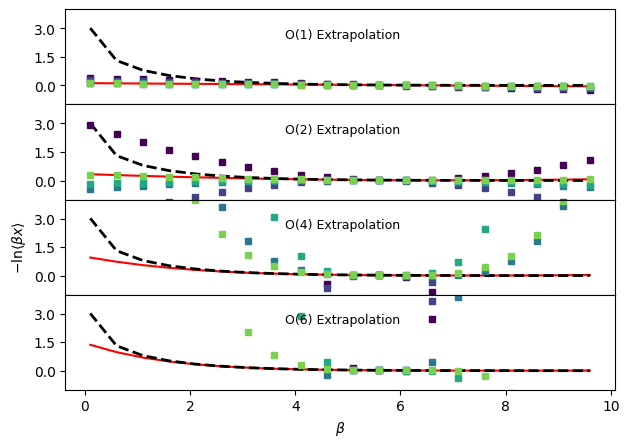

In [7]:
# Repeat comparison of results, but for -ln<B*x>, the most complicated case

fig, ax = plt.subplots(len(orders), sharex=True, sharey=True)

nsampvals = np.array((10.0 * np.ones(5)) ** np.arange(1, 6), dtype=int)
nsampcolors = plt.cm.viridis(np.arange(0.0, 1.0, float(1.0 / len(nsampvals))))

# First plot the analytical result
for a in ax:
    a.plot(betas, -np.log(betas * idealgas.x_ave(betas, vol)), "k--", linewidth=2.0)

# Next look at extrapolation with an infinite number of samples
# This is possible in the ideal gas model in both temperature and volume
for j, o in enumerate(orders):
    trueExtrap, trueDerivs = idealgas.x_beta_extrap_depend_minuslog(
        o, beta_ref, betas, vol
    )
    ax[j].plot(betas, trueExtrap, "r-", zorder=0)
    if j == len(orders) - 1:
        print(f"True extrapolation coefficients: {trueDerivs}")

for i, n in enumerate(nsampvals):
    thisinds = rng.choice(len(xdata), size=n, replace=False)

    # Get parameters for extrapolation model with this data by training it - the parameters are the derivatives
    xem_log_dep = xtrap.beta.factory_extrapmodel(
        beta=beta_ref,
        post_func="minus_log",
        data=xtrap.DataCentralMomentsVals.from_vals(
            order=orders[-1],
            uv=udata[thisinds],
            xv=xdataDepend.sel(rec=thisinds),
            deriv_dim="deriv",
            central=True,
        ),
    )
    out = xem_log_dep.predict(betas, cumsum=True)
    print(
        f"\t With N_configs = {n}: {xem_log_dep.derivs(norm=False).values.flatten()}"
    )  # Have to flatten because observable is 1-D
    for j, o in enumerate(orders):
        out.sel(order=o).plot(
            marker="s",
            ms=4,
            color=nsampcolors[i],
            ls="None",
            label=f"N={n}",
            ax=ax[j],
        )

ax[2].set_ylabel(r"$-\mathrm{ln} \langle \beta x \rangle$")
ax[-1].set_xlabel(r"$\beta$")

for j, o in enumerate(orders):
    ax[j].annotate(
        f"O({o}) Extrapolation", xy=(0.4, 0.7), xycoords="axes fraction", fontsize=9
    )

ax[0].set_ylim((-1.0, 4.0))
ax[-1].yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4, prune="both"))

fig.tight_layout()
fig.subplots_adjust(hspace=0.0)

for a in ax:
    a.set_title(None)

plt.show()